# Clasificación y estimación facial mediante Python para la seguridad en entornos   

## Descripción del dataset FGNET

In [2]:
#Librerias

import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from pathlib import Path 
from deepface import DeepFace
from tqdm import tqdm
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')


/Users/camilazuniga/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# Cargar el dataset
dataset = Path("/Users/camilazuniga/Desktop/DATA SCIENCE/AED/FGNET/images")
ruta_csv = "/Users/camilazuniga/Documents/GitHub/EDA-FGNET/FGNET_dataset.csv"


if dataset.exists():
    print("El dataset se ha cargado correctamente.")
else:
    print("El dataset no se encuentra en la ruta especificada.")

El dataset se ha cargado correctamente.


Se encontraron 1002 imágenes en el dataset.


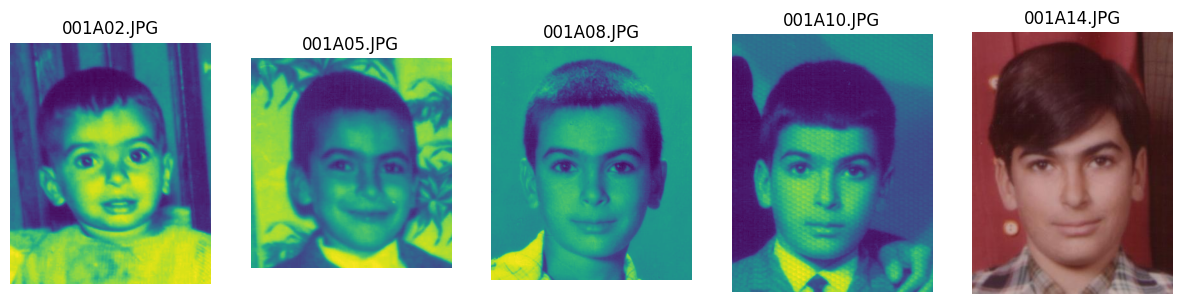

Las cinco primeras imágenes del dataset:
  - 001A02.JPG
  - 001A05.JPG
  - 001A08.JPG
  - 001A10.JPG
  - 001A14.JPG


In [5]:
# Listar imágenes en el dataset
extensiones = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}
image = [f for f in dataset.iterdir() if f.suffix.lower() in extensiones]
image = sorted(image, key=lambda x: x.name)
print(f"Se encontraron {len(image)} imágenes en el dataset.")

# Mostrar las primeras 5 imágenes
num_images_to_show = 5
plt.figure(figsize=(15, 10))
for i, image_file in enumerate(image[:num_images_to_show]):
    img = Image.open(image_file)
    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(img)
    plt.title(image_file.name)
    plt.axis('off')
plt.show()

print("Las cinco primeras imágenes del dataset:")
for img in image[:5]:
    print(f"  - {img.name}")

# Función para extraer edad del nombre del archivo
def extraer_edad(fgnet):
    stem = Path(fgnet).stem
    match = re.search(r'[a-zA-Z](\d+)', stem)
    if match:
        return int(match.group(1))
    else:
        return None


In [6]:
# Crear DataFrame con datos estructurados 
data = []

for img in image:
    stats = img.stat()
    edad = extraer_edad(img.name)
    data.append({
        'imagenes': img.name,
        'Tamaño_KB': round(stats.st_size / 1024, 2),
        'Edad': edad,
        'Sexo': None,
        'R': None,
        'G': None,
        'B': None
    })

df = pd.DataFrame(data)
df = df.sort_values('imagenes').reset_index(drop=True)

# Guardar CSV inicial
df.to_csv(ruta_csv, index=False)

print(f"CSV creado con {len(df)} imágenes")
print(f"   Edad detectada: {df['Edad'].notna().sum()}")
print(f"   Edad no detectada: {df['Edad'].isna().sum()}")



CSV creado con 1002 imágenes
   Edad detectada: 1002
   Edad no detectada: 0


In [23]:
# Cargar el dataset desde el CSV
df = pd.read_csv(ruta_csv)
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado: 1002 filas, 13 columnas


In [7]:
# Implementar DeepFace para analizar género
print("Analizando género en cada imagen...")
predicciones = []

for img_name in tqdm(df['imagenes'], desc="Procesando género"):
    img_path = dataset / img_name
    try:
        analisis = DeepFace.analyze(
            str(img_path), 
            actions=['gender'], 
            detector_backend='opencv', 
            enforce_detection=False,
            silent=True
        )
        genero = analisis[0]['dominant_gender']  
        predicciones.append(genero)
    except Exception:
        predicciones.append('No_detectado')

df['Sexo'] = predicciones

# Guardar 
df.to_csv(ruta_csv, index=False)

print(f"\nDistribución estimada de género:")
print(df['Sexo'].value_counts())

Analizando género en cada imagen...


Procesando género: 100%|██████████| 1002/1002 [01:48<00:00,  9.26it/s]


Distribución estimada de género:
Sexo
Man      719
Woman    283
Name: count, dtype: int64


La data no está representada debido a que hay más hombres que mujeres.

Distribución estimada: Sexo
- Man      719
- Woman    283

In [8]:
# Implementar la variable RGB para cada imagen
print("\nAnalizando color RGB en cada imagen...")
rgb_values = [] 
for img_name in tqdm(df['imagenes'], desc="Procesando RGB"):
    img_path = dataset / img_name
    try:
        img = cv2.imread(str(img_path))
        if img is not None:
            bgr = cv2.mean(img)[:3]  
            rgb = tuple(reversed(bgr))
            rgb_values.append(rgb)
        else:
            rgb_values.append((0, 0, 0))  
    except Exception:
        rgb_values.append((0, 0, 0))

df['RGB'] = rgb_values
df[['R', 'G', 'B']] = pd.DataFrame(df['RGB'].tolist(), index=df.index)

# Guardar 
df.to_csv(ruta_csv, index=False)

print("Análisis RGB completado")


Analizando color RGB en cada imagen...


Procesando RGB: 100%|██████████| 1002/1002 [00:00<00:00, 1750.50it/s]

Análisis RGB completado


In [9]:

# Calidad de imagenes
print("\nAnalizando calidad de imagen...")
calidad_values = []
for img_name in tqdm(df['imagenes'], desc="Procesando calidad"):
    img_path = dataset / img_name
    try:
        img = cv2.imread(str(img_path))
        if img is not None:
            calidad = cv2.Laplacian(img, cv2.CV_64F).var()
            calidad_values.append(calidad)
        else:
            calidad_values.append(0)  
    except Exception:
        calidad_values.append(0)    
    
df['Calidad'] = calidad_values
df.to_csv(ruta_csv, index=False)




Analizando calidad de imagen...


Procesando calidad: 100%|██████████| 1002/1002 [00:01<00:00, 778.25it/s]


In [10]:
# Pixeles en cada imagen
print("\nAnalizando cantidad de pixeles en cada imagen...")
pixeles_values = []
for img_name in tqdm(df['imagenes'], desc="Procesando pixeles"):
    img_path = dataset / img_name
    try:
        img = cv2.imread(str(img_path))
        if img is not None:
            pixeles = img.shape[0] * img.shape[1]
            pixeles_values.append(pixeles)
        else:
            pixeles_values.append(0)  
    except Exception:
        pixeles_values.append(0)

df['Pixeles'] = pixeles_values
df.to_csv(ruta_csv, index=False)


Analizando cantidad de pixeles en cada imagen...


Procesando pixeles: 100%|██████████| 1002/1002 [00:00<00:00, 2051.38it/s]


In [11]:
# Implementar variables de brillo
print("\nAnalizando brillo en cada imagen...")
brillo_values = []
for img_name in tqdm(df['imagenes'], desc="Procesando brillo"):
    img_path = dataset / img_name
    try:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            brillo = img.mean()
            brillo_values.append(brillo)
        else:
            brillo_values.append(0)  
    except Exception:
        brillo_values.append(0)
df['Brillo'] = brillo_values
df.to_csv(ruta_csv, index=False)
print("Análisis de brillo completado")


Analizando brillo en cada imagen...


Procesando brillo: 100%|██████████| 1002/1002 [00:00<00:00, 1972.19it/s]

Análisis de brillo completado


In [12]:
# Implementar la variable de contraste
print("\nAnalizando contraste en cada imagen...")
contraste_values = []
for img_name in tqdm(df['imagenes'], desc="Procesando contraste"):
    img_path = dataset / img_name
    try:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            contraste = img.std()
            contraste_values.append(contraste)
        else:
            contraste_values.append(0)  
    except Exception:
        contraste_values.append(0)
df['Contraste'] = contraste_values
df.to_csv(ruta_csv, index=False)
print("Análisis de contraste completado")


Analizando contraste en cada imagen...


Procesando contraste: 100%|██████████| 1002/1002 [00:00<00:00, 1563.12it/s]

Análisis de contraste completado


In [13]:
# Implementar la varible de nitidez
print("\nAnalizando nitidez en cada imagen...")
nitidez_values = []
for img_name in tqdm(df['imagenes'], desc="Procesando nitidez"):    
    img_path = dataset / img_name
    try:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            nitidez = cv2.Laplacian(img, cv2.CV_64F).var()
            nitidez_values.append(nitidez)
        else:
            nitidez_values.append(0)  
    except Exception:
        nitidez_values.append(0)
df['Nitidez'] = nitidez_values
df.to_csv(ruta_csv, index=False)
print("Análisis de nitidez completado")


Analizando nitidez en cada imagen...


Procesando nitidez: 100%|██████████| 1002/1002 [00:00<00:00, 1421.10it/s]

Análisis de nitidez completado


In [14]:
# implementar la variable menor de edad
print("\nAnalizando si la persona es menor de edad...")
menor_edad_values = []
for edad in tqdm(df['Edad'], desc="Procesando menor de edad"):
    if pd.isna(edad):
        menor_edad_values.append('Desconocido')
    elif edad < 18:
        menor_edad_values.append('Sí')
    else:
        menor_edad_values.append('No')
df['Menor_de_edad'] = menor_edad_values
df.to_csv(ruta_csv, index=False)
print("Análisis de menor de edad completado")


Analizando si la persona es menor de edad...


Procesando menor de edad: 100%|██████████| 1002/1002 [00:00<00:00, 1198714.38it/s]

Análisis de menor de edad completado


In [15]:
# Mostrar el dataset 
print("=" * 60)
print("DATASET FGNET") #con datos estructurados"
print("=" * 60)

print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")

print("\n Primeras 10 filas del dataset:")
display(df.head(10))

print("\n Información del dataset:")
df.info()

print("\n Estadísticas descriptivas:")
display(df.describe())


DATASET FGNET

Dimensiones: 1002 filas × 14 columnas

Columnas: ['imagenes', 'Tamaño_KB', 'Edad', 'Sexo', 'R', 'G', 'B', 'RGB', 'Calidad', 'Pixeles', 'Brillo', 'Contraste', 'Nitidez', 'Menor_de_edad']

 Primeras 10 filas del dataset:


,imagenes,Tamaño_KB,Edad,Sexo,R,G,B,RGB,Calidad,Pixeles,Brillo,Contraste,Nitidez,Menor_de_edad
0,001A02.JPG,9.55,2,Woman,102.936847,102.936847,102.936847,"(102.93684728745984, 102.93684728745984, 102.9...",14.565980,123906,102.936847,52.954320,14.565980,Sí
1,001A05.JPG,12.55,5,Man,133.466402,133.466402,133.466402,"(133.46640236073256, 133.46640236073256, 133.4...",10.937652,177572,133.466402,47.626867,10.937652,Sí
2,001A08.JPG,12.54,8,Man,138.786665,138.786665,138.786665,"(138.78666468886746, 138.78666468886746, 138.7...",14.906851,202245,138.786665,29.309509,14.906851,Sí
3,001A10.JPG,14.12,10,Man,111.491709,111.491709,111.491709,"(111.49170883317224, 111.49170883317224, 111.4...",25.312660,158301,111.491709,48.384509,25.312660,Sí
4,001A14.JPG,10.57,14,Man,114.376567,64.713975,63.699782,"(114.3765671746721, 64.71397548763055, 63.6997...",14.457277,128017,79.450089,40.450270,12.233492,Sí
5,001A16.JPG,58.06,16,Man,126.296435,126.296435,126.296435,"(126.29643549263342, 126.29643549263342, 126.2...",106.820466,493308,126.296435,54.556714,106.820466,Sí
6,001A18.JPG,16.39,18,Man,150.180489,76.964194,61.682092,"(150.18048877097957, 76.96419425560529, 61.682...",12.698099,217116,97.172659,38.755604,10.074829,No
7,001A19.JPG,18.52,19,Man,156.591782,76.827312,58.073008,"(156.59178216974675, 76.82731220054757, 58.073...",53.271038,187008,98.544036,39.245843,50.946136,No
8,001A22.JPG,34.81,22,Man,159.241437,128.307665,113.630621,"(159.24143701982277, 128.3076646260037, 113.63...",25.655989,230644,135.912935,55.874923,23.676302,No
9,001A28.JPG,14.51,28,Man,94.887594,87.523791,87.852513,"(94.88759449562959, 87.523791243405, 87.852512...",10.911139,203184,89.786479,34.446613,9.051681,No



 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   imagenes       1002 non-null   object 
 1   Tamaño_KB      1002 non-null   float64
 2   Edad           1002 non-null   int64  
 3   Sexo           1002 non-null   object 
 4   R              1002 non-null   float64
 5   G              1002 non-null   float64
 6   B              1002 non-null   float64
 7   RGB            1002 non-null   object 
 8   Calidad        1002 non-null   float64
 9   Pixeles        1002 non-null   int64  
 10  Brillo         1002 non-null   float64
 11  Contraste      1002 non-null   float64
 12  Nitidez        1002 non-null   float64
 13  Menor_de_edad  1002 non-null   object 
dtypes: float64(8), int64(2), object(4)
memory usage: 109.7+ KB

 Estadísticas descriptivas:


,Tamaño_KB,Edad,R,G,B,Calidad,Pixeles,Brillo,Contraste,Nitidez
count,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000
mean,44.114681,15.840319,108.362976,87.325224,80.161416,34.592948,202213.066866,92.802639,49.787973,31.685342
std,12.187962,12.867280,24.267356,21.779225,24.085586,43.397043,28346.161994,21.055310,11.574078,43.381593
min,7.850000,0.000000,47.103134,33.284418,23.008612,3.049299,110827.000000,37.678779,18.205912,3.049299
25%,39.195000,6.000000,90.828113,71.777986,63.035480,14.219920,194889.000000,78.100225,41.611730,11.251506
50%,45.260000,13.000000,105.448688,85.086661,77.339972,21.826176,203102.500000,90.319603,49.309756,18.788824
75%,51.062500,22.000000,123.351280,100.428520,93.868196,38.433359,208566.000000,105.633029,56.895394,34.870997
max,97.910000,69.000000,212.378051,159.890851,163.178075,685.121769,493308.000000,159.890851,89.819889,687.280925


## Análisis Exploratorio de Datos I

### i. Análisis exploratorio Univariado 

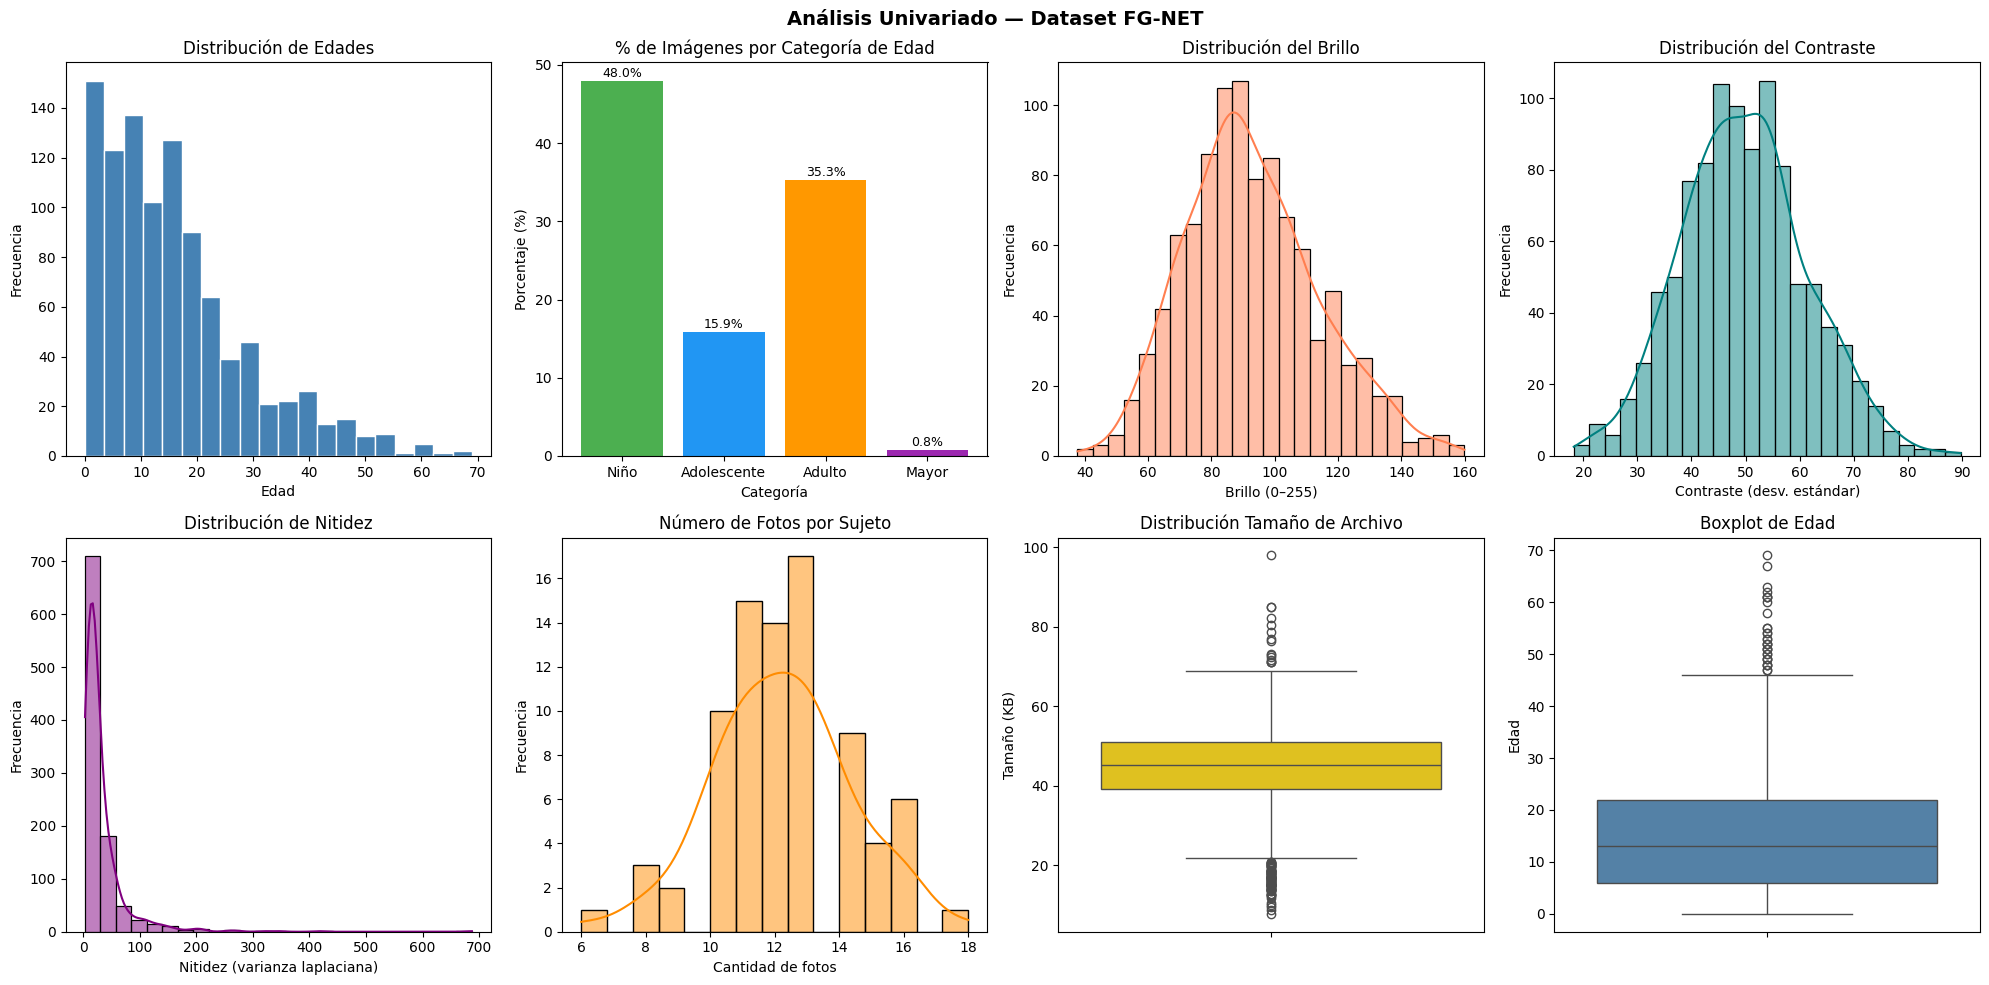

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Análisis Univariado — Dataset FG-NET', fontsize=14, fontweight='bold')

axes[0,0].hist(df['Edad'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribución de Edades')
axes[0,0].set_xlabel('Edad')
axes[0,0].set_ylabel('Frecuencia')

cat_bins = [0, 12, 17, 59, float('inf')]
cat_labels = ['Niño', 'Adolescente', 'Adulto', 'Mayor']
df['Categoria_Edad'] = pd.cut(df['Edad'], bins=cat_bins, labels=cat_labels, right=True, include_lowest=True)

cat_pct = df['Categoria_Edad'].value_counts(normalize=True) * 100
orden = ['Niño','Adolescente','Adulto','Mayor']
cat_pct = cat_pct.reindex([c for c in orden if c in cat_pct.index])

axes[0,1].bar(cat_pct.index, cat_pct.values, color=['#4CAF50','#2196F3','#FF9800','#9C27B0'])
axes[0,1].set_title('% de Imágenes por Categoría de Edad')
axes[0,1].set_xlabel('Categoría')
axes[0,1].set_ylabel('Porcentaje (%)')

for i, v in enumerate(cat_pct.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

sns.histplot(df['Brillo'].dropna(), bins=25, kde=True, ax=axes[0,2], color='coral')
axes[0,2].set_title('Distribución del Brillo')
axes[0,2].set_xlabel('Brillo (0–255)')
axes[0,2].set_ylabel('Frecuencia')

sns.histplot(df['Contraste'].dropna(), bins=25, kde=True, ax=axes[0,3], color='teal')
axes[0,3].set_title('Distribución del Contraste')
axes[0,3].set_xlabel('Contraste (desv. estándar)')
axes[0,3].set_ylabel('Frecuencia')

sns.histplot(df['Nitidez'].dropna(), bins=25, kde=True, ax=axes[1,0], color='purple')
axes[1,0].set_title('Distribución de Nitidez')
axes[1,0].set_xlabel('Nitidez (varianza laplaciana)')
axes[1,0].set_ylabel('Frecuencia')

fotos_por_sujeto = df['imagenes'].str[:3].value_counts()

sns.histplot(fotos_por_sujeto, bins=15, ax=axes[1,1], color='darkorange', kde=True)
axes[1,1].set_title('Número de Fotos por Sujeto')
axes[1,1].set_xlabel('Cantidad de fotos')
axes[1,1].set_ylabel('Frecuencia')

sns.boxplot(y=df['Tamaño_KB'], ax=axes[1,2], color='gold')
axes[1,2].set_title('Distribución Tamaño de Archivo')
axes[1,2].set_ylabel('Tamaño (KB)')

sns.boxplot(y=df['Edad'], ax=axes[1,3], color='steelblue')
axes[1,3].set_title('Boxplot de Edad')
axes[1,3].set_ylabel('Edad')

plt.tight_layout()
plt.show()



### ii. Análisis exploratorio Bivariado. 

El análisis bivariado estudia la relación entre pares de variables. Se organiza en tres partes: (1) matriz de correlación entre todas las variables numéricas, (2) relaciones entre variables numéricas y categóricas mediante gráficos comparativos, y (3) relación entre dos variables categóricas (Sexo y Categoria_Edad) mediante tabla de contingencia y prueba Chi-cuadrado.

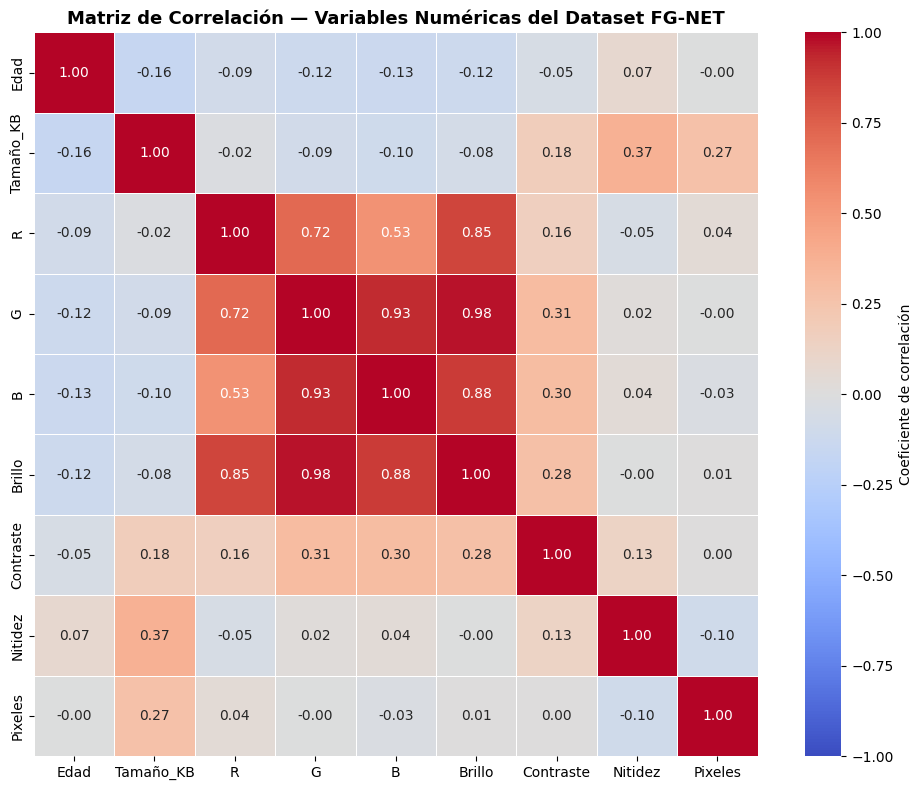

In [18]:
# 1. Matriz de correlación entre variables numéricas (heatmap)
variables_numericas = ['Edad', 'Tamaño_KB', 'R', 'G', 'B', 'Brillo', 'Contraste', 'Nitidez', 'Pixeles']

matriz_corr = df[variables_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'label': 'Coeficiente de correlación'})
plt.title('Matriz de Correlación — Variables Numéricas del Dataset FG-NET',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación de la matriz de correlación:** los canales de color R, G y B están fuertemente correlacionados entre sí y con el Brillo (correlaciones entre 0.53 y 0.98), lo cual es esperable porque el brillo se calcula a partir de la intensidad de los píxeles; esto indica redundancia entre estas variables y sugiere que para el análisis multivariado basta conservar una de ellas. La Nitidez muestra una correlación moderada con el Tamaño_KB (0.37): las imágenes con más detalle generan archivos más pesados por la compresión JPG. En cambio, la correlación entre Edad y Nitidez es débil (0.07), lo que se analiza con más detalle a continuación.

In [31]:
# Análisis de Correlación de Pearson 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.datasets import make_regression

# 2. Calculo de correlaciones individuales
print("\n2. Calculando correlaciones individuales...")

def calcular_correlaciones(df, variables):
    """Calcula correlación de Pearson y muestra resultados detallados"""
    # Calcular correlación con scipy
    r, p_valor = pearsonr(x, y)

    print(f"\nCorrelación entre {nombres[0]} y {nombres[1]}:")
    print(f"  • Coeficiente de Pearson (r): {r:.4f}")
    print(f"  • P-valor: {p_valor:.6f}")

    # Interpretación de la fuerza de correlación
    if abs(r) < 0.1:
        fuerza = "muy débil"
    elif abs(r) < 0.3:
        fuerza = "débil"
    elif abs(r) < 0.5:
        fuerza = "moderada"
    elif abs(r) < 0.7:
        fuerza = "moderadamente fuerte"
    else:
        fuerza = "fuerte"
    
    direccion = "positiva" if r > 0 else "negativa"
    significancia = "significativa" if p_valor < 0.05 else "no significativa"
    
    print(f"  • Interpretación: Correlación {fuerza} {direccion}")
    print(f"  • Significancia estadística: {significancia} (α = 0.05)")
    
    return r, p_valor

# Ejemplos de diferentes tipos de correlación
correlaciones_a_evaluar = [
    ('Edad', 'Brillo'),
    ('Edad', 'Contraste'),
    ('Edad', 'Nitidez'),
    ('Brillo', 'Contraste'),
    ('Brillo', 'Nitidez'),
    ('Contraste', 'Nitidez'),
    ('R', 'G'),
    ('R', 'B'),
    ('G', 'B'),
    ('Tamaño_KB', 'Pixeles'),
]

resultados = []

for var1, var2 in correlaciones_a_evaluar:
    x = df[var1].dropna()
    y = df[var2].dropna()
    nombres = (var1, var2)
    
    # Asegurarse de que ambos conjuntos tengan la misma longitud
    min_len = min(len(x), len(y))
    x = x.iloc[:min_len]
    y = y.iloc[:min_len]
    
    r, p_valor = calcular_correlaciones(df, (var1, var2))
    resultados.append((var1, var2, r, p_valor))

# Mostrar resultados en un DataFrame
resultados_df = pd.DataFrame(resultados, columns=['Variable 1', 'Variable 2', 'Coeficiente de Pearson (r)', 'P-valor'])
print("\nResumen de correlaciones calculadas:")
display(resultados_df)





2. Calculando correlaciones individuales...

Correlación entre Edad y Brillo:
  • Coeficiente de Pearson (r): -0.1200
  • P-valor: 0.000140
  • Interpretación: Correlación débil negativa
  • Significancia estadística: significativa (α = 0.05)

Correlación entre Edad y Contraste:
  • Coeficiente de Pearson (r): -0.0483
  • P-valor: 0.126527
  • Interpretación: Correlación muy débil negativa
  • Significancia estadística: no significativa (α = 0.05)

Correlación entre Edad y Nitidez:
  • Coeficiente de Pearson (r): 0.0737
  • P-valor: 0.019678
  • Interpretación: Correlación muy débil positiva
  • Significancia estadística: significativa (α = 0.05)

Correlación entre Brillo y Contraste:
  • Coeficiente de Pearson (r): 0.2801
  • P-valor: 0.000000
  • Interpretación: Correlación débil positiva
  • Significancia estadística: significativa (α = 0.05)

Correlación entre Brillo y Nitidez:
  • Coeficiente de Pearson (r): -0.0007
  • P-valor: 0.983208
  • Interpretación: Correlación muy débil 

,Variable 1,Variable 2,Coeficiente de Pearson (r),P-valor
0,Edad,Brillo,-0.120000,1.403454e-04
1,Edad,Contraste,-0.048302,1.265270e-01
2,Edad,Nitidez,0.073676,1.967765e-02
3,Brillo,Contraste,0.280142,1.592421e-19
4,Brillo,Nitidez,-0.000666,9.832078e-01
5,Contraste,Nitidez,0.132241,2.678272e-05
6,R,G,0.718409,8.275352e-160
7,R,B,0.532561,1.760662e-74
8,G,B,0.927900,0.000000e+00
9,Tamaño_KB,Pixeles,0.269113,4.382587e-18


In [40]:
# 3. MATRIZ DE CORRELACIÓN COMPLETA
print("\n3. Calculando matriz de correlación completa...")
# Seleccionar variables numéricas para la matriz de correlación

variables_numericas = ['Edad', 'Tamaño_KB', 'R', 'G', 'B', 'Brillo', 'Contraste', 'Nitidez', 'Pixeles']
matriz_corr = df[variables_numericas].corr()


print(f"\nMatriz de correlación completa Pearson:") 
print("="*50)
display(matriz_corr)


# Encontrar las correlaciones más fuertes (excluyendo la diagonal)
correlaciones_fuertes = []
for i in range(len(matriz_corr)):
    for j in range(i + 1, len(matriz_corr)):
        r = matriz_corr.iloc[i, j]
        if abs(r) > 0.5:  # Umbral para considerar fuerte
            correlaciones_fuertes.append((matriz_corr.index[i], matriz_corr.columns[j], r))

print(f"\nCorrelaciones más fuertes encontradas:") #(excluyendo la diagonal)
print("="*50)

for var1, var2, r in correlaciones_fuertes:
    print(f"{var1} - {var2}: {r:.2f}")



3. Calculando matriz de correlación completa...

Matriz de correlación completa Pearson:


,Edad,Tamaño_KB,R,G,B,Brillo,Contraste,Nitidez,Pixeles
Edad,1.000000,-0.157243,-0.090372,-0.118754,-0.128622,-0.120000,-0.048302,0.073676,-0.003000
Tamaño_KB,-0.157243,1.000000,-0.018490,-0.093389,-0.102862,-0.076491,0.175788,0.372382,0.269113
R,-0.090372,-0.018490,1.000000,0.718409,0.532561,0.850409,0.161260,-0.049938,0.040448
G,-0.118754,-0.093389,0.718409,1.000000,0.927900,0.975778,0.306072,0.019491,-0.004580
B,-0.128622,-0.102862,0.532561,0.927900,1.000000,0.877305,0.297557,0.036401,-0.028162
Brillo,-0.120000,-0.076491,0.850409,0.975778,0.877305,1.000000,0.280142,-0.000666,0.007537
Contraste,-0.048302,0.175788,0.161260,0.306072,0.297557,0.280142,1.000000,0.132241,0.002932
Nitidez,0.073676,0.372382,-0.049938,0.019491,0.036401,-0.000666,0.132241,1.000000,-0.098434
Pixeles,-0.003000,0.269113,0.040448,-0.004580,-0.028162,0.007537,0.002932,-0.098434,1.000000



Correlaciones más fuertes encontradas:
R - G: 0.72
R - B: 0.53
R - Brillo: 0.85
G - B: 0.93
G - Brillo: 0.98
B - Brillo: 0.88



4. Creando visualizaciones...


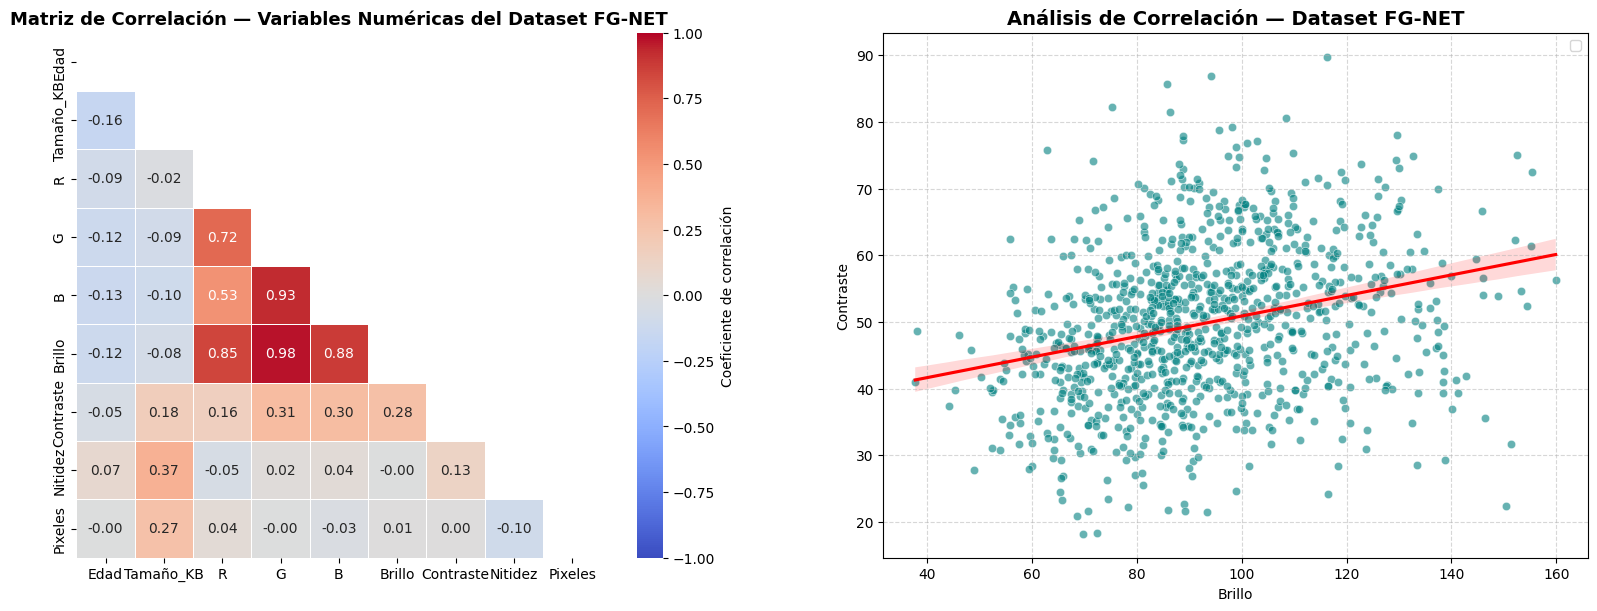

In [41]:
# 4. VISUALIZACIONES DE CORRELACIÓN
print("\n4. Creando visualizaciones...")

#configurar subplots para mostrar múltiples gráficos de dispersión
fig = plt.figure(figsize=(20, 15))

#heatmap de la matriz de correlación
plt.subplot(2, 2, 1)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={'label': 'Coeficiente de correlación'}, mask=mask)
plt.title('Matriz de Correlación — Variables Numéricas del Dataset FG-NET', fontsize=13, fontweight='bold')

# Scatter plot - Correlación positiva fuerte
plt.subplot(2, 2, 2)
sns.scatterplot(x='Brillo', y='Contraste', data=df, color='teal', alpha=0.6)
plt.title('Brillo vs Contraste (Correlación positiva fuerte)', fontsize=12)
plt.xlabel('Brillo')
plt.ylabel('Contraste') 

plt.title('Análisis de Correlación — Dataset FG-NET', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

# linea de regresión para Brillo vs Contraste
sns.regplot(x='Brillo', y='Contraste', data=df, scatter=False, color='red', line_kws={'label':"y={0:.1f}x+{1:.1f}".format(*np.polyfit(df['Brillo'], df['Contraste'], 1))})
plt.legend()

In [42]:
# 5. CORRELACIÓN DE SPEARMAN - CÁLCULOS
from scipy.stats import spearmanr
from scipy import stats
import numpy as np

print("="*60)
print("ANÁLISIS DE CORRELACIÓN DE SPEARMAN")
print("="*60)

def calcular_correlacion_spearman(x, y, nombres):
    """Calcula correlación de Spearman y muestra resultados detallados"""
    # Calcular correlación con scipy
    coef_spearman, p_valor = spearmanr(x, y)

    print(f"\nCorrelación entre {nombres[0]} y {nombres[1]}:")
    print(f"  • Coeficiente de Spearman (ρ): {coef_spearman:.4f}")
    print(f"  • P-valor: {p_valor:.6f}")

    # Interpretación de la fuerza de correlación
    if abs(coef_spearman) < 0.1:
        fuerza = "muy débil"
    elif abs(coef_spearman) < 0.3:
        fuerza = "débil"
    elif abs(coef_spearman) < 0.5:
        fuerza = "moderada"
    elif abs(coef_spearman) < 0.7:
        fuerza = "moderadamente fuerte"
    else:
        fuerza = "fuerte"   

    direccion = "positiva" if coef_spearman > 0 else "negativa"
    significancia = "significativa" if p_valor < 0.05 else "no significativa"

    print(f"  • Interpretación: Correlación {fuerza} {direccion}")
    print(f"  • Significancia estadística: {significancia} (α = 0.05)")

    return coef_spearman, p_valor

# calcular correlaciones de Spearman
print("\nCalculando correlaciones de Spearman...")

correlaciones_spearman = [
    ('Edad', 'Brillo'),
    ('Edad', 'Contraste'),
    ('Edad', 'Nitidez'),
    ('Brillo', 'Contraste'),
    ('Brillo', 'Nitidez'),
    ('Contraste', 'Nitidez'),
    ('R', 'G'),
    ('R', 'B'),
    ('G', 'B'),
    ('Tamaño_KB', 'Pixeles'),
]

resultados_spearman = []

for var1, var2 in correlaciones_spearman:
    x = df[var1].dropna()
    y = df[var2].dropna()
    nombres = (var1, var2)
    
    # Asegurarse de que ambos conjuntos tengan la misma longitud
    min_len = min(len(x), len(y))
    x = x.iloc[:min_len]
    y = y.iloc[:min_len]
    
    coef_spearman, p_valor = calcular_correlacion_spearman(x, y, nombres)
    resultados_spearman.append((var1, var2, coef_spearman, p_valor))    

# Mostrar resultados en un DataFrame
resultados_spearman_df = pd.DataFrame(resultados_spearman, columns=['Variable 1', 'Variable 2', 'Coeficiente de Spearman (ρ)', 'P-valor'])
print("\nResumen de correlaciones de Spearman calculadas:")
display(resultados_spearman_df)





ANÁLISIS DE CORRELACIÓN DE SPEARMAN

Calculando correlaciones de Spearman...

Correlación entre Edad y Brillo:
  • Coeficiente de Spearman (ρ): -0.1377
  • P-valor: 0.000012
  • Interpretación: Correlación débil negativa
  • Significancia estadística: significativa (α = 0.05)

Correlación entre Edad y Contraste:
  • Coeficiente de Spearman (ρ): -0.0110
  • P-valor: 0.727611
  • Interpretación: Correlación muy débil negativa
  • Significancia estadística: no significativa (α = 0.05)

Correlación entre Edad y Nitidez:
  • Coeficiente de Spearman (ρ): 0.0411
  • P-valor: 0.193154
  • Interpretación: Correlación muy débil positiva
  • Significancia estadística: no significativa (α = 0.05)

Correlación entre Brillo y Contraste:
  • Coeficiente de Spearman (ρ): 0.3145
  • P-valor: 0.000000
  • Interpretación: Correlación moderada positiva
  • Significancia estadística: significativa (α = 0.05)

Correlación entre Brillo y Nitidez:
  • Coeficiente de Spearman (ρ): -0.0112
  • P-valor: 0.723225

,Variable 1,Variable 2,Coeficiente de Spearman (ρ),P-valor
0,Edad,Brillo,-0.137700,1.218695e-05
1,Edad,Contraste,-0.011017,7.276113e-01
2,Edad,Nitidez,0.041144,1.931542e-01
3,Brillo,Contraste,0.314469,1.945880e-24
4,Brillo,Nitidez,-0.011202,7.232250e-01
5,Contraste,Nitidez,0.195386,4.451795e-10
6,R,G,0.730052,1.614177e-167
7,R,B,0.538866,1.524576e-76
8,G,B,0.915540,0.000000e+00
9,Tamaño_KB,Pixeles,0.291375,4.648325e-21


Text(0, 0.5, 'Brillo (0–255)')

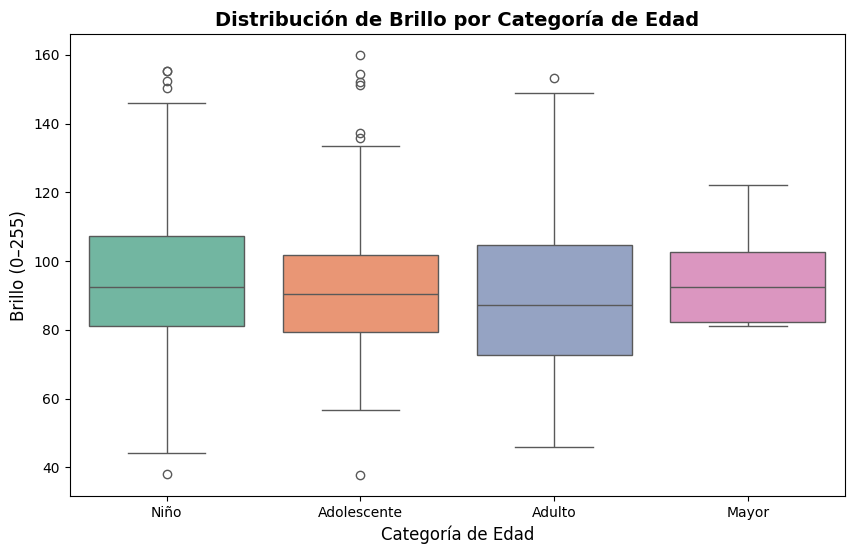

In [43]:
# 6. gráfico de boxplot para comparar la distribución de brillo por categoría de edad
plt.figure(figsize=(10, 6))
sns.boxplot(x='Categoria_Edad', y='Brillo', data=df, palette='Set2')
plt.title('Distribución de Brillo por Categoría de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Categoría de Edad', fontsize=12)
plt.ylabel('Brillo (0–255)', fontsize=12)


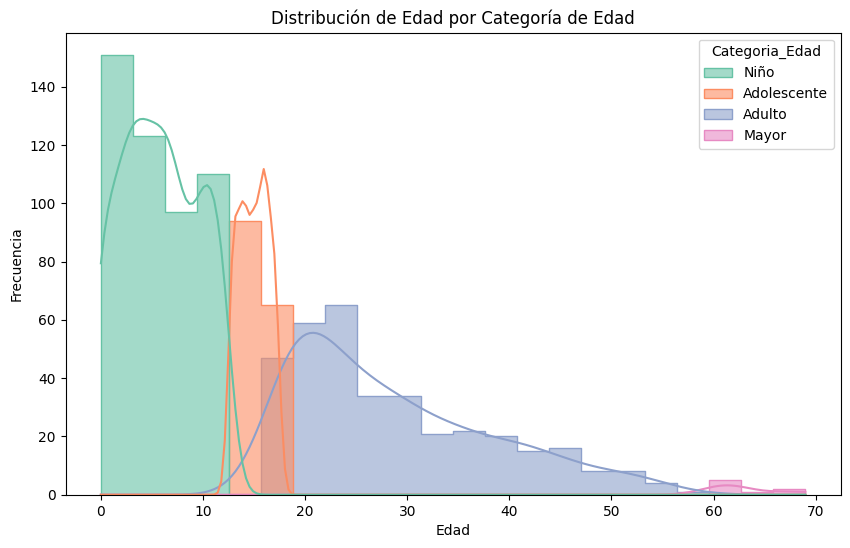

In [44]:
# 7. histograma de distribución de Edad por categoría de edad
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Edad', hue='Categoria_Edad', kde=True, element='step', palette='Set2', alpha=0.6)
plt.title('Distribución de Edad por Categoría de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

In [45]:
#prueba de normalidad para Edad
from scipy.stats import shapiro 
stat, p = shapiro(df['Edad'])
print('Estadístico=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print("Los datos parecen seguir una distribución normal")
else:
    print("Los datos no parecen seguir una distribución normal")

Estadístico=0.903, p=0.000
Los datos no parecen seguir una distribución normal


In [47]:
#Prueba de Mann-Whitney U para comparar años de experiencia entre solo los sexos
from scipy.stats import mannwhitneyu
Man = df[df['Sexo'] == 'Woman']['Edad']
Women = df[df['Sexo'] == 'Man']['Edad']
stat, p = mannwhitneyu(Man, Women)
print('Estadístico=%.3f, p=%.3f' % (stat, p))

Estadístico=86884.000, p=0.000


In [48]:
# Prueba t de Student para comparar Edad entre Sexo
from scipy.stats import ttest_ind 
stat, p = ttest_ind(Man, Women)
print('Estadístico=%.3f, p=%.3f' % (stat, p))

Estadístico=-3.370, p=0.001


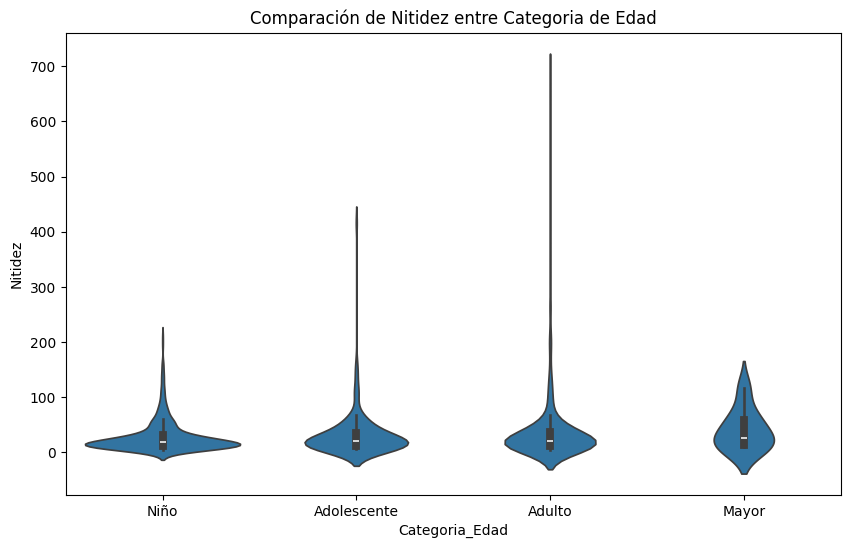

In [51]:
# 8. gráfico de violín para comparar la nitidez entre categoria de edad
plt.figure(figsize=(10, 6))
sns.violinplot(x='Categoria_Edad', y='Nitidez', data=df)
plt.title('Comparación de Nitidez entre Categoria de Edad')
plt.show()

In [52]:
# Prueba de kruskal para comparar Nitidez entre categoria de edad
from scipy.stats import kruskal 
groups = [group['Nitidez'].values for name, group in df.groupby('Categoria_Edad')]
stat, p = kruskal(*groups)
print('Estadístico=%.3f, p=%.3f' % (stat, p))
print(groups)

Estadístico=2.341, p=0.505
[array([ 14.56597969,  10.93765213,  14.90685056,  25.31265991,
        11.6621526 ,  26.22029402, 163.35245737, 159.11783415,
        10.82328414,  26.30908503,   7.59271461,  23.05726585,
        28.98929286,  12.78128802,   8.03539388,  30.19134438,
        27.68019704,  13.59362385,  10.83206137,   6.29558886,
         7.16194749,  13.91951763,  11.81082365,  16.64665039,
         9.27488658, 136.19472506,  24.88877132,  12.27122526,
         8.60055263,   7.61204489,  19.6434266 ,  47.73827637,
        10.01973382, 112.94164943,   5.18130519,  10.97663335,
        55.46999156,  24.17921811,   8.51145934,   7.43702784,
        99.27489879,  39.37365765,  27.80390431,  66.35025087,
        53.40996388,  91.1045423 , 140.65497982,  71.74501194,
        44.64297426,  52.68683981,  69.57993963,  57.00909059,
        50.5112111 , 122.10384568,  82.1974846 ,  77.5895472 ,
        54.63749336,   9.31937744,  20.39824832,  13.70158342,
        11.44836884,   7.50

In [53]:
# ANVA para comparar la Nitidez entre Categoria de Edad
from scipy.stats import f_oneway
stat, p = f_oneway(*groups)
print('Estadístico=%.3f, p=%.3f' % (stat, p))

Estadístico=2.359, p=0.070


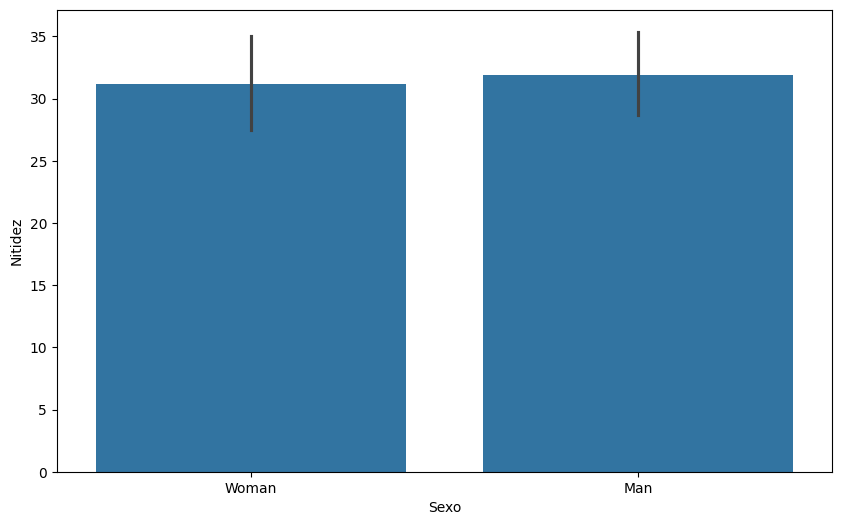

In [56]:
# 9. gráfico de barras con error para comparar la Nitidez entre Sexo
plt.figure(figsize=(10, 6))
sns.barplot(x='Sexo', y='Nitidez', data=df)
plt.show()

In [58]:
# Tabla de contingencia para Categoria_Edad y Sexo
contingency_table = pd.crosstab(df['Categoria_Edad'], df['Sexo'])
print("\nTabla de Contingencia (Categoria_Edad vs Sexo):")
print(contingency_table)

# En porcentajes
contingency_table = pd.crosstab(df['Categoria_Edad'], df['Sexo'], normalize='all') * 100
print("\nTabla de Contingencia (Categoria_Edad vs Sexo) en porcentajes:")
print(contingency_table)


Tabla de Contingencia (Categoria_Edad vs Sexo):
Sexo            Man  Woman
Categoria_Edad            
Niño            327    154
Adolescente     115     44
Adulto          269     85
Mayor             8      0

Tabla de Contingencia (Categoria_Edad vs Sexo) en porcentajes:
Sexo                  Man      Woman
Categoria_Edad                      
Niño            32.634731  15.369261
Adolescente     11.477046   4.391218
Adulto          26.846307   8.483034
Mayor            0.798403   0.000000


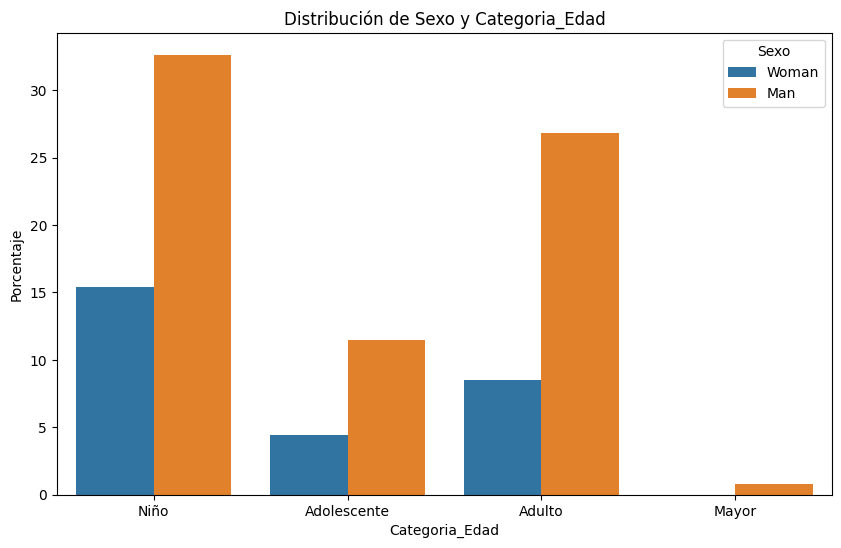

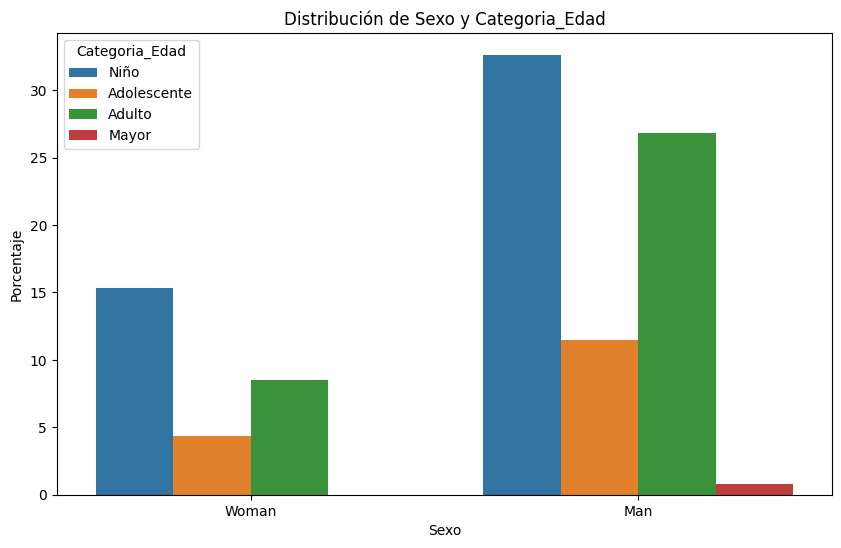

In [ ]:
# 10. Gráfico de barras agrupadas para Sexo y Categoria_Edad en porcentaje
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Categoria_Edad', hue='Sexo', stat='percent')
plt.title('Distribución de Sexo y Categoria_Edad')
plt.xlabel('Categoria_Edad')
plt.ylabel('Porcentaje')
plt.legend(title='Sexo')
plt.show()  

# 11. Gráfico de barras agrupadas para Sexo por Categoria_Edad en porcentaje condicional
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sexo', hue='Categoria_Edad', stat='percent')
plt.title('Distribución de Sexo y Categoria_Edad')
plt.xlabel('Sexo')
plt.ylabel('Porcentaje')
plt.legend(title='Categoria_Edad')
plt.show()  

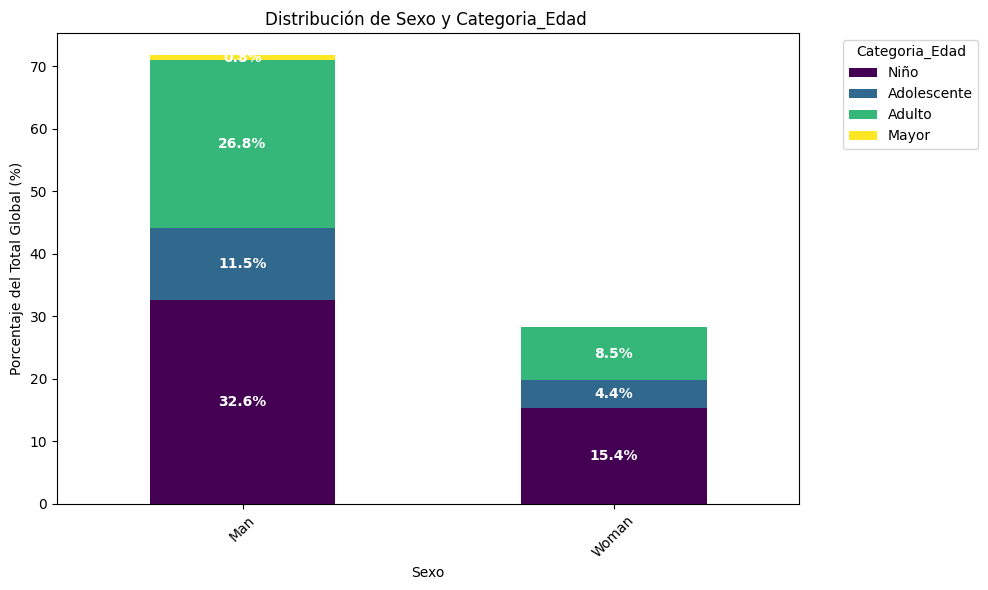

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

tabla_total = pd.crosstab(df['Sexo'], df['Categoria_Edad'], normalize='all') * 100


ax = tabla_total.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

# 12. grafico de Distribución de Sexo y Categoria_Edad

plt.title('Distribución de Sexo y Categoria_Edad ')
plt.xlabel('Sexo')
plt.ylabel('Porcentaje del Total Global (%)')
plt.xticks(rotation=45)
plt.legend(title='Categoria_Edad', bbox_to_anchor=(1.05, 1), loc='upper left')


for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0: 
        x, y = p.get_xy() 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

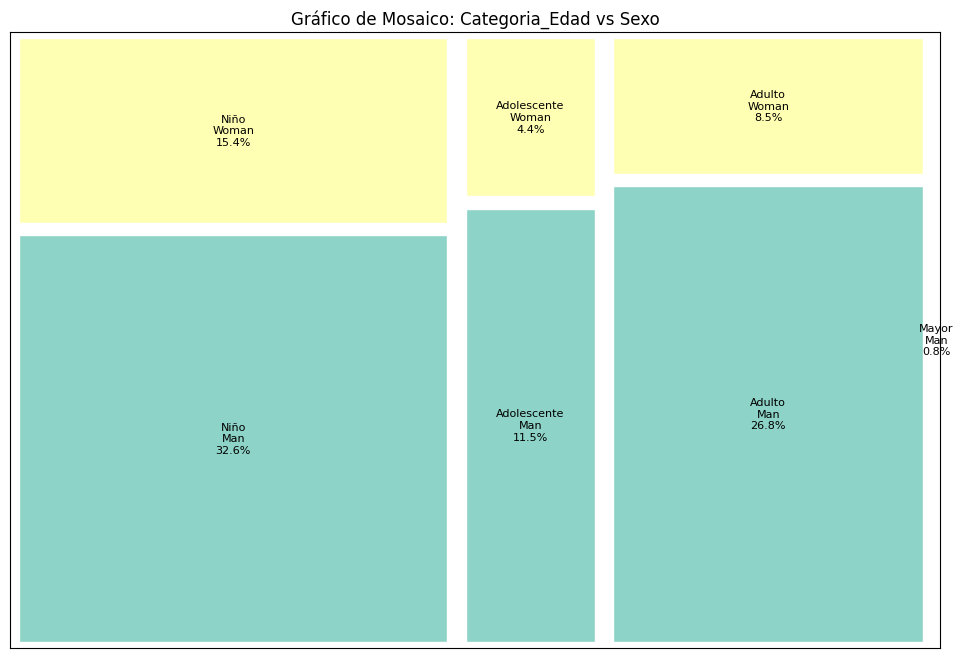

In [ ]:
# 13. Gráfico de mosaico:
import matplotlib.pyplot as plt
try:
       from statsmodels.graphics.mosaicplot import mosaic
except Exception:
       import matplotlib.patches as patches

       def mosaic(data, columns, title=None, axes_label=True, gap=0.02):
              """
              Simple fallback mosaic plot if statsmodels is not installed.
              - data: DataFrame
              - columns: [row_category_col, column_category_col]
              - gap: fraction of the unit (0-1) used as spacing
              """
              ax = plt.gca()
              ct = pd.crosstab(data[columns[0]], data[columns[1]], normalize='all')
              row_sums = ct.sum(axis=1)
              x_start = 0.0
              colors = plt.cm.Set3(range(len(ct.columns)))

              for j_row, row in enumerate(ct.index):
                     width = row_sums[row]
                     y_start = 0.0
                     for i_col, col in enumerate(ct.columns):
                            val = ct.loc[row, col]
                            if val <= 0 or width <= 0:
                                   continue
                            height = val / width
                            rect = patches.Rectangle(
                                   (x_start + gap / 2, y_start + gap / 2),
                                   max(0.0, width - gap),
                                   max(0.0, height - gap),
                                   facecolor=colors[i_col % len(colors)],
                                   edgecolor='white'
                            )
                            ax.add_patch(rect)
                            if axes_label:
                                   ax.text(
                                          x_start + width / 2,
                                          y_start + height / 2,
                                          f"{row}\n{col}\n{val*100:.1f}%",
                                          ha='center', va='center', fontsize=8
                                   )
                            y_start += height
                     x_start += width

              ax.set_xlim(0, 1)
              ax.set_ylim(0, 1)
              ax.set_xticks([])
              ax.set_yticks([])
              if title:
                     ax.set_title(title)
              return ax


plt.figure(figsize=(12, 8))

labelizer = lambda k: "" 

mosaic(df, ['Categoria_Edad', 'Sexo'], 
       title='Gráfico de Mosaico: Categoria_Edad vs Sexo',
       axes_label=True,
       gap=0.02) 

plt.show()

### iii. Análisis exploratorio Multivariado

Varianza explicada por componente:
  PC1: 44.7%  (acumulada: 44.7%)
  PC2: 18.7%  (acumulada: 63.4%)
  PC3: 14.0%  (acumulada: 77.4%)
  PC4: 10.2%  (acumulada: 87.6%)
  PC5: 6.7%  (acumulada: 94.3%)
  PC6: 5.1%  (acumulada: 99.5%)
  PC7: 0.5%  (acumulada: 100.0%)
  PC8: 0.0%  (acumulada: 100.0%)


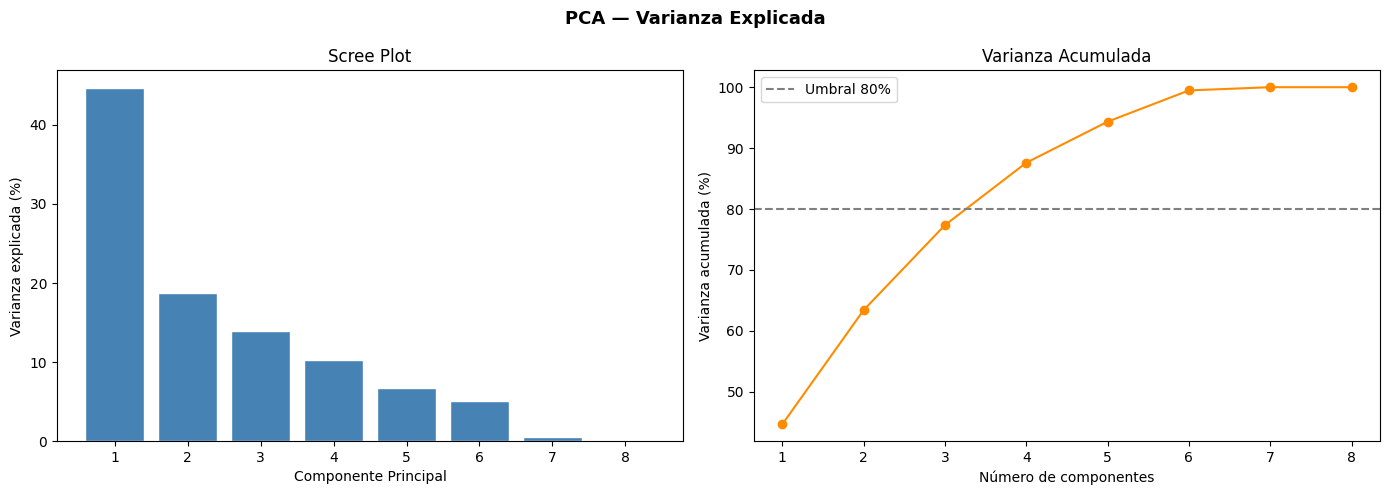

In [ ]:
# 1. PCA: ajuste y varianza explicada
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Variables técnicas de imagen (excluyendo Calidad por redundancia y Edad como agrupadora)
vars_pca = ['Tamaño_KB', 'R', 'G', 'B', 'Brillo', 'Contraste', 'Nitidez', 'Pixeles']

scaler = StandardScaler()
df_estandarizado = pd.DataFrame(
    scaler.fit_transform(df[vars_pca]),
    columns=vars_pca,
    index=df.index
)
X = df_estandarizado.values

pca = PCA()
componentes = pca.fit_transform(X)

var_exp = pca.explained_variance_ratio_ * 100
var_acum = var_exp.cumsum()

print("Varianza explicada por componente:")
for i, (v, a) in enumerate(zip(var_exp, var_acum), start=1):
    print(f"  PC{i}: {v:.1f}%  (acumulada: {a:.1f}%)")

# Scree plot y varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA — Varianza Explicada', fontsize=13, fontweight='bold')

axes[0].bar(range(1, len(var_exp)+1), var_exp, color='steelblue', edgecolor='white')
axes[0].set_title('Scree Plot')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza explicada (%)')

axes[1].plot(range(1, len(var_acum)+1), var_acum, marker='o', color='darkorange')
axes[1].axhline(80, color='gray', linestyle='--', label='Umbral 80%')
axes[1].set_title('Varianza Acumulada')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

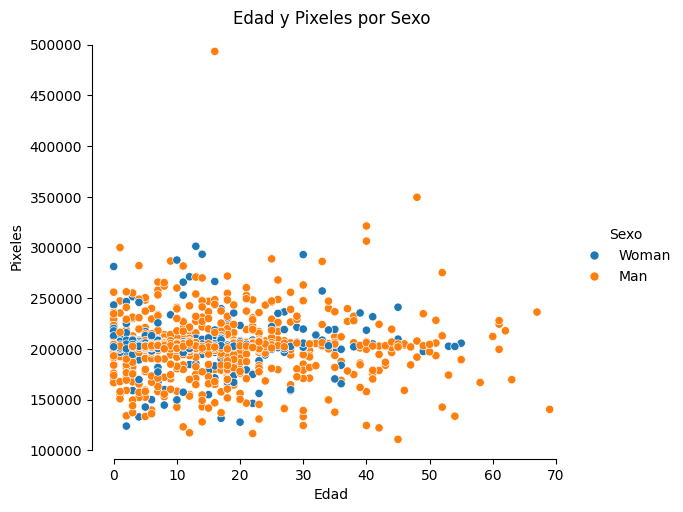

In [20]:
import pandas as pd
import seaborn as sns

ruta_csv = "/Users/camilazuniga/Documents/GitHub/EDA-FGNET/FGNET_dataset.csv"
if 'df' not in globals():
    df = pd.read_csv(ruta_csv)

# 2. Grafico de dispersion entre la edad y el peso por sexo

g = sns.relplot(data=df, x="Edad", y="Pixeles", hue="Sexo", 
                height=5, aspect=1.2)
g.set(title="Edad y Pixeles por Sexo", xlabel="Edad", ylabel="Pixeles")

# "Desespinar" el gráfico
sns.despine(trim=True)




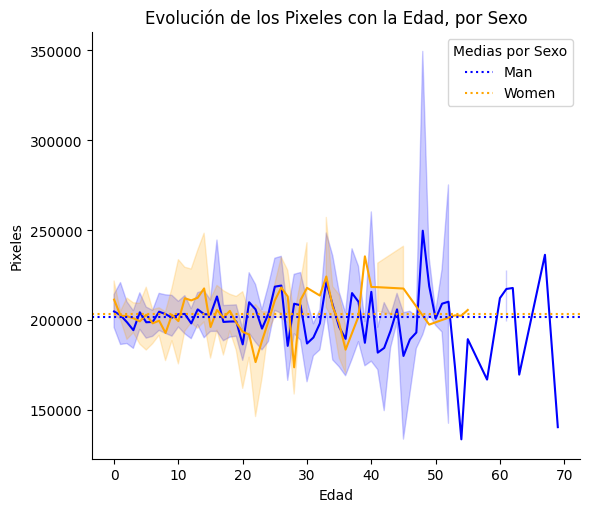

In [ ]:
# 3. Gráfico de líneas para investigar la evolución de los Pixeles con la edad

# Cálculo de las medias para pixeles por sexo
medias=df.groupby('Sexo')['Pixeles'].mean().to_list()


g = sns.relplot(data=df, x="Edad", y="Pixeles",
            hue="Sexo", hue_order=['Man','Woman'], palette=['blue','orange'],
           height=5, aspect=1.2, kind='line', legend=False)

g.set(title = "Evolución de los Pixeles con la Edad, por Sexo",
      xlabel="Edad", ylabel="Pixeles");

plt.axhline(y=medias[0],color='blue',linestyle='dotted',label="Man")
plt.axhline(y=medias[1],color='orange',linestyle='dotted',label="Women")
# Configuramos la leyenda
plt.legend(title="Medias por Sexo",fancybox=True)


plt.show()

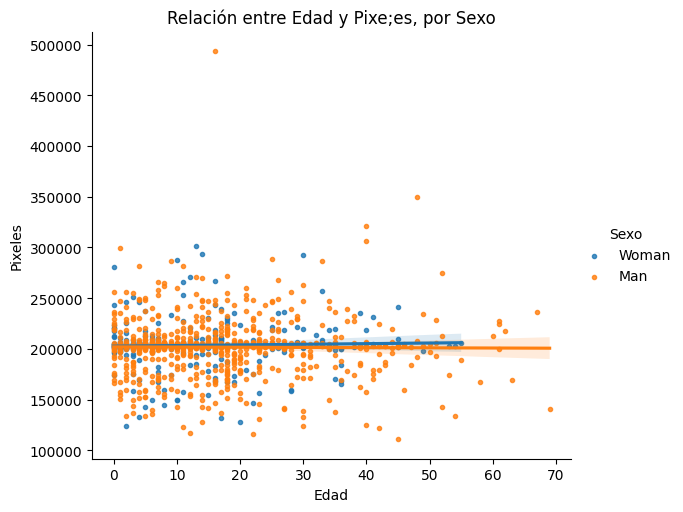

In [35]:
# 4. Gráfico de dispersión con recta de tendencias superpuesta

# Dibujamos el gráfico de dispersión edad-pixeles, diferenciando por sexo
g = sns.lmplot(data=df, x="Edad", y="Pixeles", hue="Sexo", markers='.', height=5, aspect=1.2)

# Indicamos el título y las etiquetas de los ejes (X e Y)
g.set(title = "Relación entre Edad y Pixe;es, por Sexo", xlabel = "Edad", ylabel = "Pixeles");

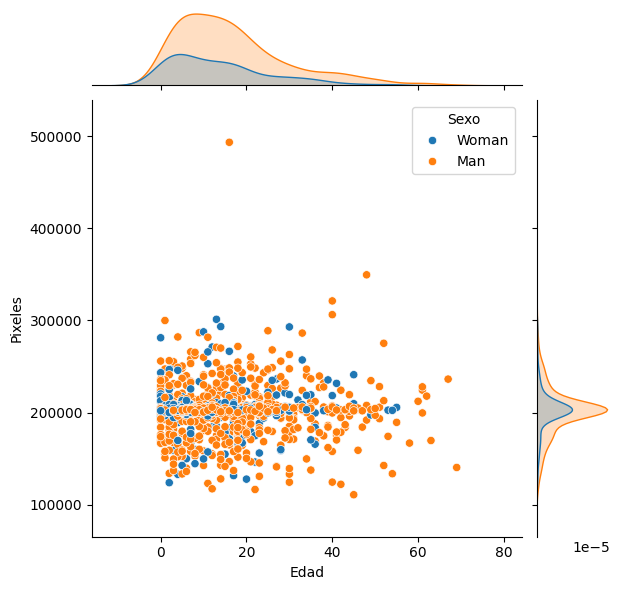

In [36]:
# 5. Gráfico de dispersión con histogramas superpuestos, diferenciados por cat_var en color
sns.jointplot(df,x='Edad',y='Pixeles',hue='Sexo');

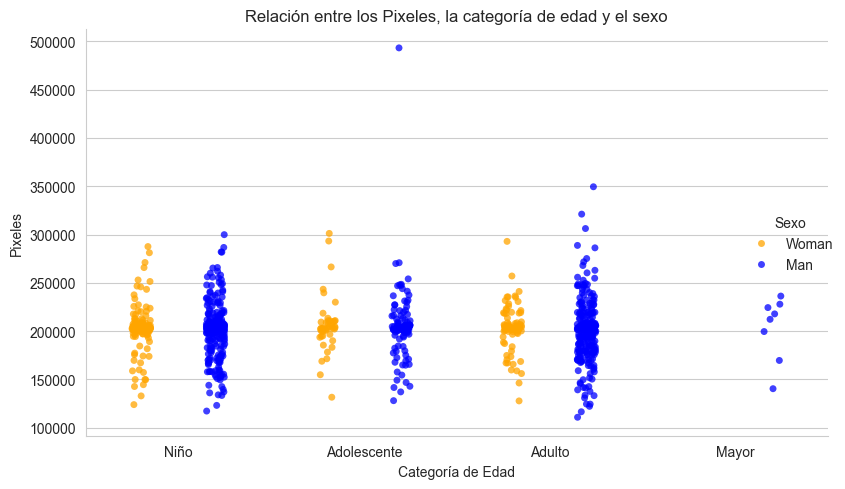

In [44]:
# 6. Gráfico de puntos por categoría de edad y sexo
if 'Categoria_Edad' not in df.columns:
    cat_bins = [0, 12, 17, 59, float('inf')]
    cat_labels = ['Niño', 'Adolescente', 'Adulto', 'Mayor']
    df['Categoria_Edad'] = pd.cut(df['Edad'], bins=cat_bins, labels=cat_labels, right=True, include_lowest=True)

palette = {'Man': 'blue', 'Woman': 'orange'}

sns.set_style('whitegrid')

g = sns.catplot(
    data=df,
    x="Categoria_Edad",
    y="Pixeles",
    hue="Sexo",
    kind="strip",
    dodge=True,
    jitter=True,
    palette=palette,
    height=5,
    aspect=1.5,
    alpha=0.75
)

g.set(
    title="Relación entre los Pixeles, la categoría de edad y el sexo",
    xlabel="Categoría de Edad",
    ylabel="Pixeles"
)

plt.tight_layout()
plt.show()

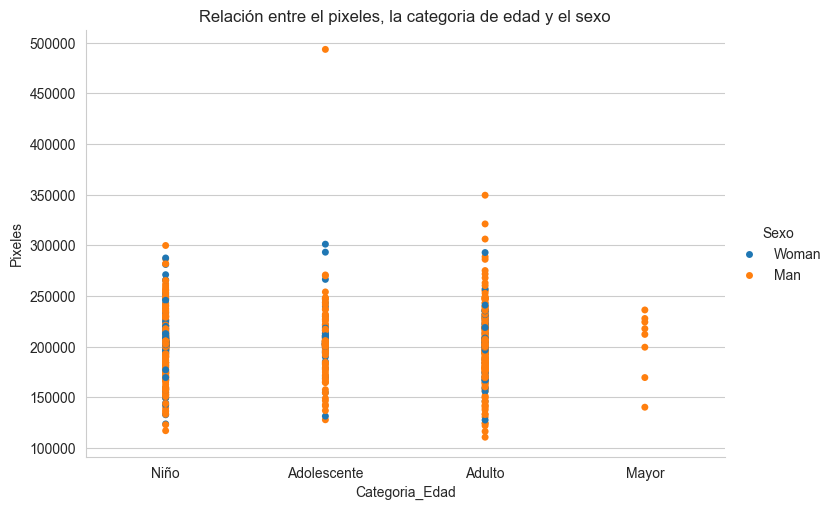

In [45]:
# 7. Gráfico de cajas del pixeles por categoria de edad y por sexo. catplot con jitter=False
grafico = sns.catplot(data=df, x="Categoria_Edad", y="Pixeles", hue="Sexo",
                      jitter=False, aspect=1.5)


grafico.set(title = "Relación entre el pixeles, la categoria de edad y el sexo",
            xlabel = "Categoria_Edad", ylabel = "Pixeles");

# Mostramos el gráfico
plt.show()

/Users/camilazuniga/Library/Python/3.9/lib/python/site-packages/seaborn/categorical.py:3399: UserWarning: 48.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/camilazuniga/Library/Python/3.9/lib/python/site-packages/seaborn/categorical.py:3399: UserWarning: 23.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/camilazuniga/Library/Python/3.9/lib/python/site-packages/seaborn/categorical.py:3399: UserWarning: 28.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/camilazuniga/Library/Python/3.9/lib/python/site-packages/seaborn/categorical.py:3399: UserWarning: 52.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/camilazuniga/

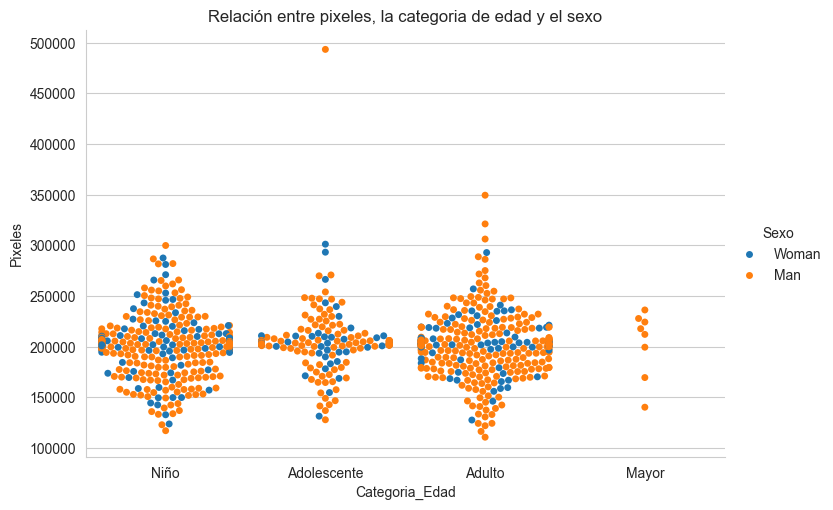

In [47]:
# 8. Gráfico de cajas del pixeles por categoria de edad y por sexo. catplot con kind='swarm'
grafico = sns.catplot(data=df, x="Categoria_Edad", y="Pixeles", hue="Sexo",
                      kind="swarm", aspect=1.5)

grafico.set(title = "Relación entre pixeles, la categoria de edad y el sexo",
            xlabel = "Categoria_Edad", ylabel = "Pixeles");


plt.show()

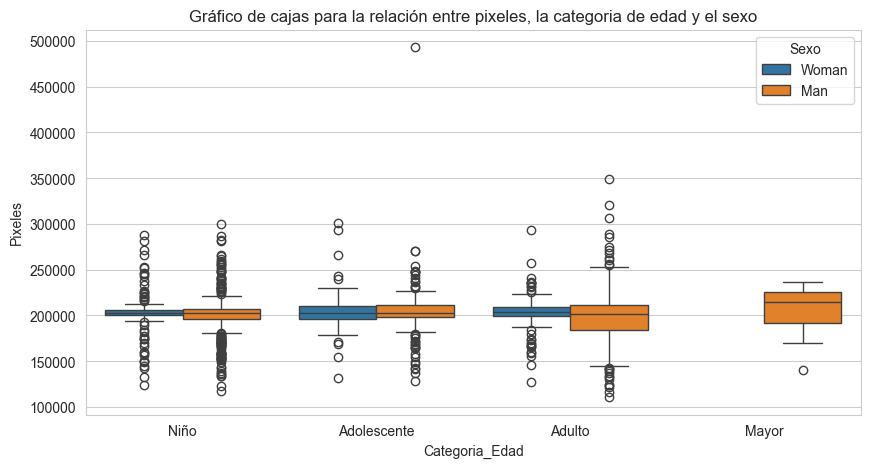

In [48]:
# 9. Tamaño del lienzo
plt.figure(figsize=(10,5))

# Gráfico de cajas del peso por provincia y por sexo
g = sns.boxplot(data=df, x="Categoria_Edad", y="Pixeles", hue="Sexo")


g.set(title = "Gráfico de cajas para la relación entre pixeles, la categoria de edad y el sexo",
            xlabel = "Categoria_Edad", ylabel = "Pixeles");


plt.show()

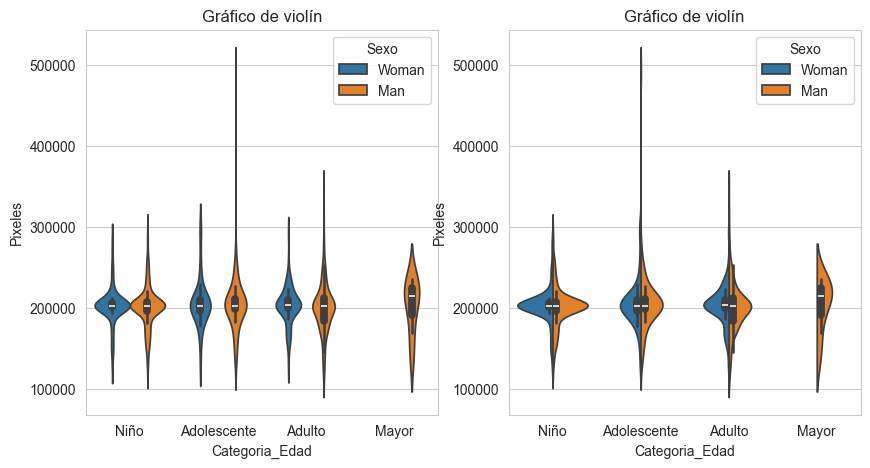

In [49]:
# 10. Tamaño del lienzo
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
# Gráficos de violines diferentes
g = sns.violinplot(data=df, x="Categoria_Edad", y="Pixeles", hue="Sexo")
g.set(title = "Gráfico de violín",
            xlabel = "Categoria_Edad", ylabel = "Pixeles");
plt.subplot(1,2,2)
# Gráficos de violines asimétricos
g = sns.violinplot(data=df, x="Categoria_Edad", y="Pixeles", hue="Sexo",split=True)
g.set(title = "Gráfico de violín",
            xlabel = "Categoria_Edad", ylabel = "Pixeles");

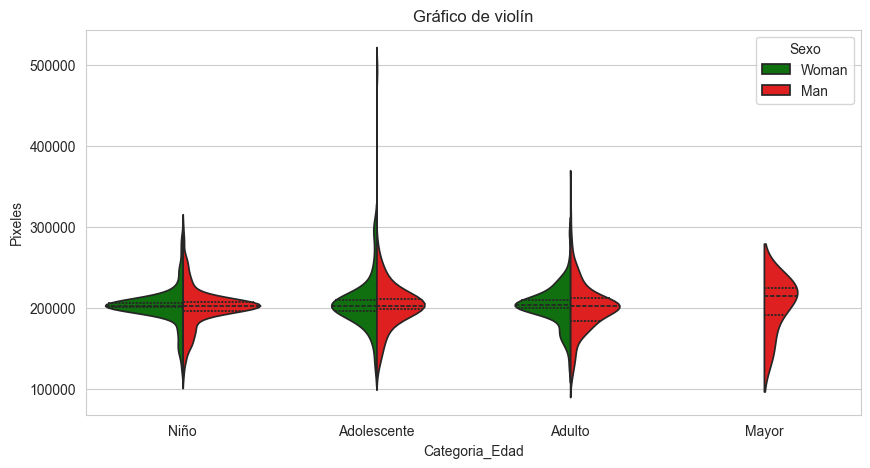

In [51]:
# 11. Tamaño del lienzo
plt.figure(figsize=(10,5))

# Dibujamos los violines con los cuartiles identificados con líneas
g = sns.violinplot(data=df, x="Categoria_Edad", y="Pixeles", hue="Sexo",
                  split=True, inner="quart",
                  palette={"Man": "red", "Woman": "green"})
g.set(title = "Gráfico de violín",
            xlabel = "Categoria_Edad", ylabel = "Pixeles");

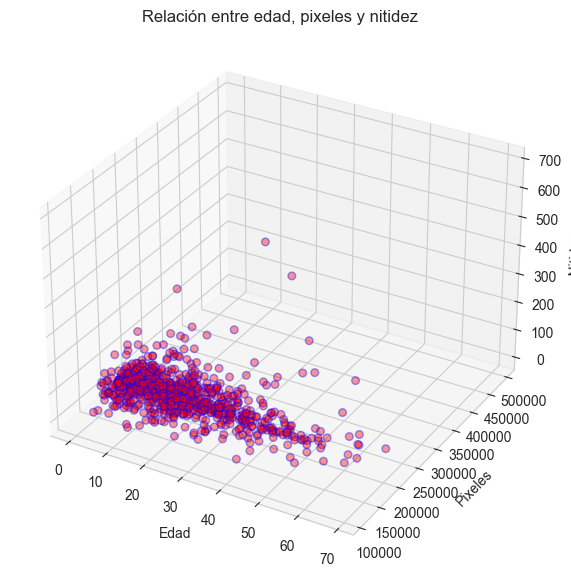

In [ ]:
# Importamos el módulo para gráficos 3D en mpl_toolkits
from mpl_toolkits import mplot3d

# 12. Representamos la relación entre edad, peso y nitidez

# Dimensionamos lienzo
plt.figure(figsize = (9,7))
# creamos ejes
ax = plt.axes(projection='3d')

# representamos los datos

ax.scatter('Edad','Pixeles','Nitidez',data=df,
           edgecolors="blue",s=30,alpha=0.4,color="red")

# Integramos el título del gráfico
ax.set_title('Relación entre edad, pixeles y nitidez')

# Especificamos las etiquetas de los ejes
ax.set_xlabel('Edad')
ax.set_ylabel('Pixeles')
ax.set_zlabel('Nitidez')
plt.show()

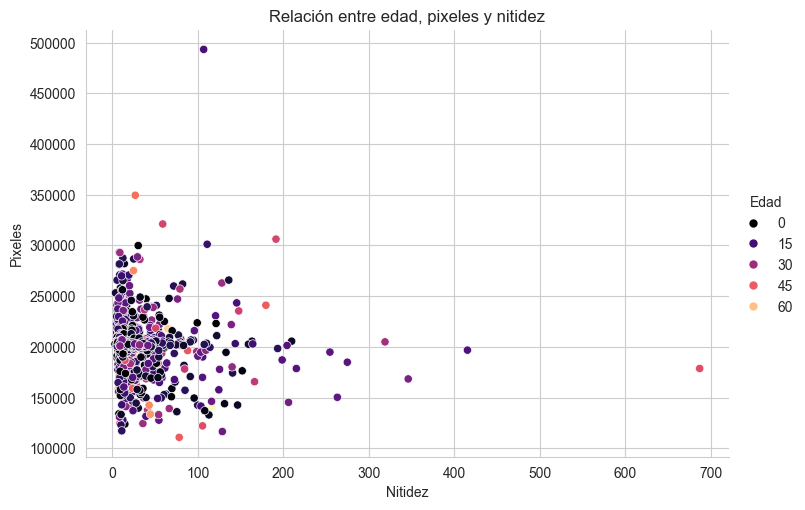

In [54]:
# 13. Relación entre la edad y el pixeles por la nitidez
g = sns.relplot(data=df, x="Nitidez", y="Pixeles",
                hue="Edad", palette="magma",aspect=1.5)
# introducimos rótulos
g.set(title = "Relación entre edad, pixeles y nitidez", xlabel = "Nitidez", ylabel = "Pixeles");